In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI ML-LastSem/Week4/Copy of Copy of devnagari digit.zip"
extract_to = "/content/devnagari_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

os.listdir(extract_to)

['DevanagariHandwrittenDigitDataset']

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms

DATASET_ROOT = "/content/devnagari_data/DevanagariHandwrittenDigitDataset"
TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

IMG_SIZE = 28

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# load dataset with transformation : grayscale, resize to 28x28, normalize to [0,1]
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

full_train = datasets.ImageFolder(TRAIN_DIR, transform=transform)
test_ds = datasets.ImageFolder(TEST_DIR,  transform=transform)

# split train into train/val
val_size = int(0.1 * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds,   batch_size=128)
test_loader = DataLoader(test_ds,  batch_size=128)

len(train_ds), len(val_ds), len(test_ds)

(15300, 1700, 3000)

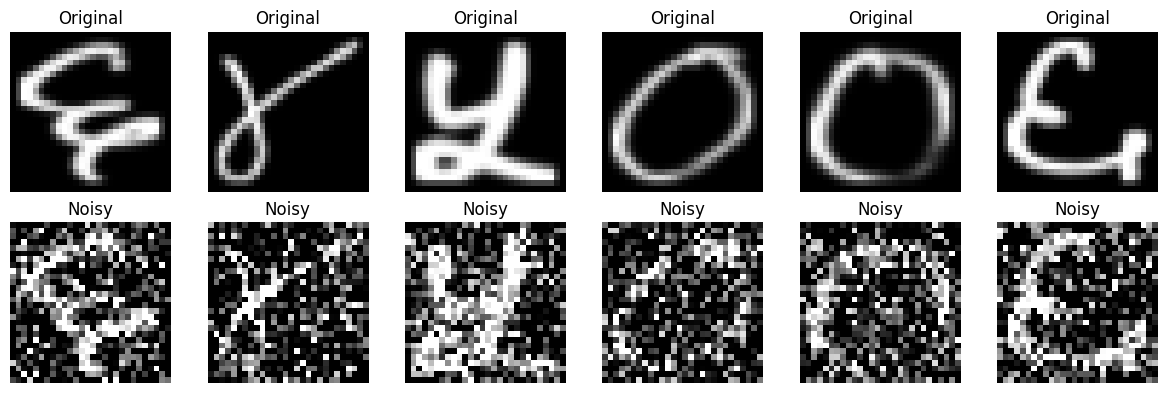

In [5]:
# add gaussian noise and clip to [0,1]
def add_noise(imgs, noise_factor=0.5):
    noisy = imgs + noise_factor * torch.randn_like(imgs)
    return torch.clamp(noisy, 0., 1.)

# visualize original vs noisy
sample_imgs, _ = next(iter(train_loader))
noisy_sample = add_noise(sample_imgs)

n = 6
fig, axes = plt.subplots(2, n, figsize=(12, 4))
for i in range(n):
    axes[0, i].imshow(sample_imgs[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy_sample[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Noisy")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# convolutional denoising autoencoder — 4 layers deep (2 encoder, 2 decoder)
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2), # 14x14
            nn.Conv2d(32, 64, 3, padding=1), # 14x14
            nn.ReLU(),
            nn.MaxPool2d(2),   # 7x7
            nn.Conv2d(64, 128, 3, padding=1), # 7x7
            nn.ReLU(),
            nn.MaxPool2d(2),  # 3x3 (latent)
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2), # 7x7
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1),  # 13x13
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1),  # 25x25
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=1, padding=0),  # 28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = DenoisingAutoencoder().to(device)
model

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(1, 1))
    (7): Sigmoid()
  )
)

In [7]:
# quick check output shape matches input
x_test_shape = torch.randn(1, 1, 28, 28).to(device)
model(x_test_shape).shape

torch.Size([1, 1, 28, 28])

In [8]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

EPOCHS = 20
NOISE_FACTOR = 0.5

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # train
    model.train()
    batch_losses = []
    for imgs, _ in train_loader:
        imgs  = imgs.to(device)
        noisy = add_noise(imgs, NOISE_FACTOR).to(device)

        optimizer.zero_grad()
        recon = model(noisy)
        loss  = criterion(recon, imgs)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # val
    model.eval()
    v_losses = []
    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs  = imgs.to(device)
            noisy = add_noise(imgs, NOISE_FACTOR).to(device)
            recon = model(noisy)
            v_losses.append(criterion(recon, imgs).item())

    train_losses.append(np.mean(batch_losses))
    val_losses.append(np.mean(v_losses))

    print(f"Epoch {epoch+1}/{EPOCHS}  train_loss: {train_losses[-1]:.4f}  val_loss: {val_losses[-1]:.4f}")

Epoch 1/20  train_loss: 0.4932  val_loss: 0.3721
Epoch 2/20  train_loss: 0.3149  val_loss: 0.2802
Epoch 3/20  train_loss: 0.2659  val_loss: 0.2551
Epoch 4/20  train_loss: 0.2493  val_loss: 0.2442
Epoch 5/20  train_loss: 0.2403  val_loss: 0.2364
Epoch 6/20  train_loss: 0.2353  val_loss: 0.2342
Epoch 7/20  train_loss: 0.2306  val_loss: 0.2277
Epoch 8/20  train_loss: 0.2271  val_loss: 0.2262
Epoch 9/20  train_loss: 0.2247  val_loss: 0.2227
Epoch 10/20  train_loss: 0.2225  val_loss: 0.2208
Epoch 11/20  train_loss: 0.2208  val_loss: 0.2193
Epoch 12/20  train_loss: 0.2192  val_loss: 0.2189
Epoch 13/20  train_loss: 0.2177  val_loss: 0.2186
Epoch 14/20  train_loss: 0.2171  val_loss: 0.2174
Epoch 15/20  train_loss: 0.2161  val_loss: 0.2164
Epoch 16/20  train_loss: 0.2154  val_loss: 0.2141
Epoch 17/20  train_loss: 0.2145  val_loss: 0.2148
Epoch 18/20  train_loss: 0.2138  val_loss: 0.2127
Epoch 19/20  train_loss: 0.2137  val_loss: 0.2133
Epoch 20/20  train_loss: 0.2123  val_loss: 0.2127


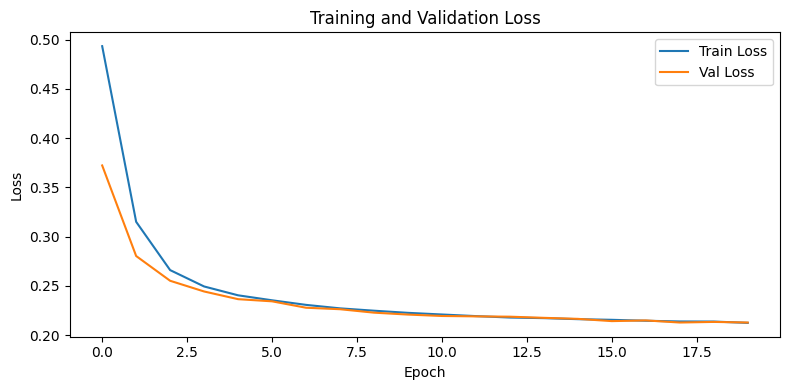

In [9]:
# loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

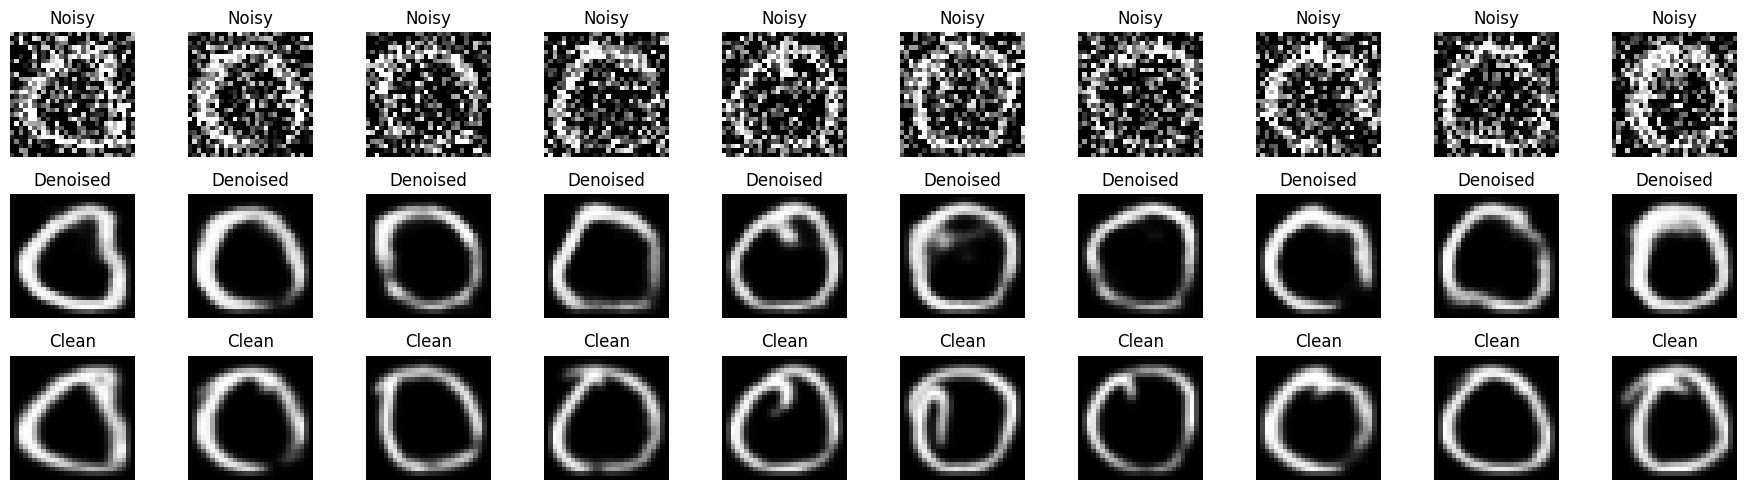

In [10]:
# evaluate — show noisy, denoised, original
model.eval()

test_imgs, _ = next(iter(test_loader))
test_imgs  = test_imgs.to(device)
noisy_imgs = add_noise(test_imgs, NOISE_FACTOR).to(device)

with torch.no_grad():
    denoised = model(noisy_imgs)

n = 10
fig, axes = plt.subplots(3, n, figsize=(18, 5))

for i in range(n):
    axes[0, i].imshow(noisy_imgs[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title("Noisy")
    axes[0, i].axis('off')

    axes[1, i].imshow(denoised[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title("Denoised")
    axes[1, i].axis('off')

    axes[2, i].imshow(test_imgs[i].cpu().squeeze(), cmap='gray')
    axes[2, i].set_title("Clean")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

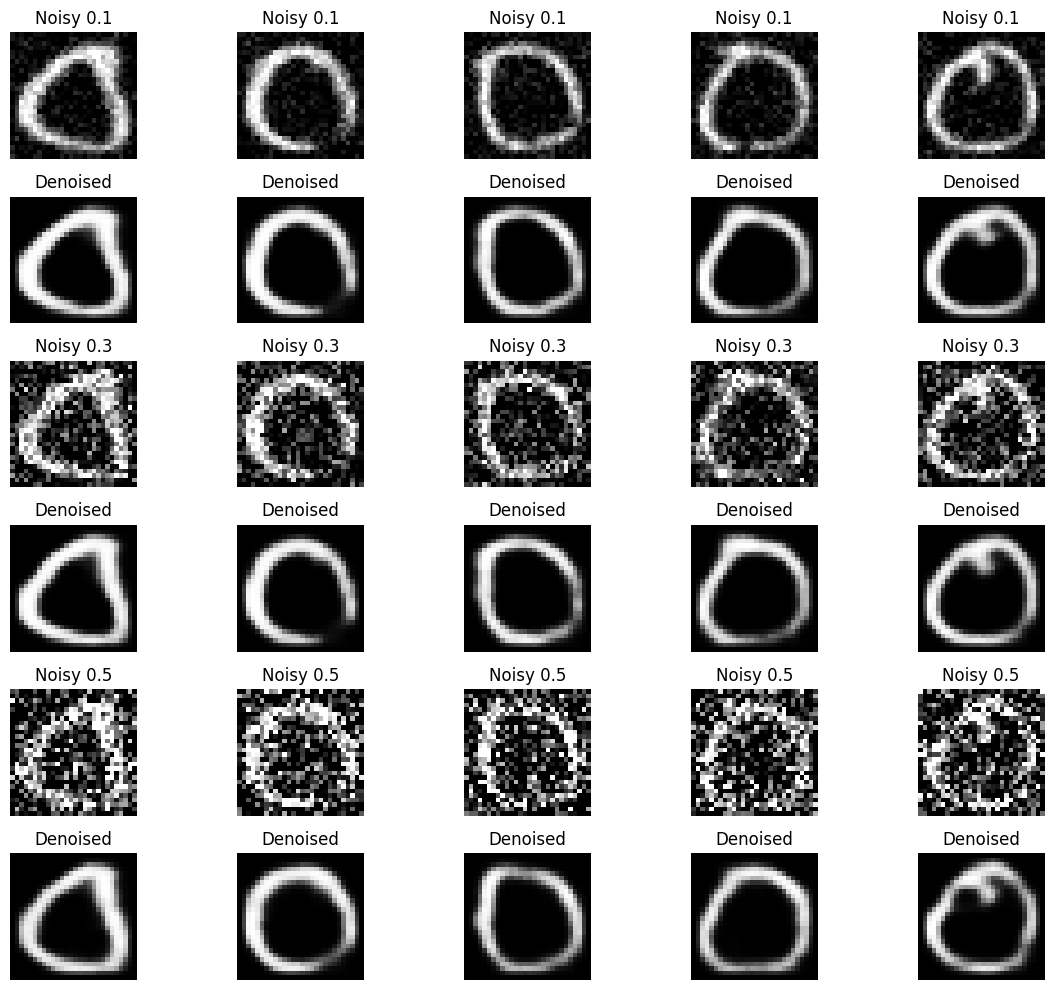

In [11]:
# experiment — compare noise factors 0.1, 0.3, 0.5
model.eval()
noise_levels = [0.1, 0.3, 0.5]

sample, _ = next(iter(test_loader))
sample = sample[:5].to(device)

fig, axes = plt.subplots(len(noise_levels) * 2, 5, figsize=(12, 10))

for row, nf in enumerate(noise_levels):
    noisy = add_noise(sample, nf)
    with torch.no_grad():
        denoised = model(noisy)

    for col in range(5):
        axes[row*2,col].imshow(noisy[col].cpu().squeeze(),    cmap='gray')
        axes[row*2,col].set_title(f"Noisy {nf}")
        axes[row*2,col].axis('off')

        axes[row*2 + 1, col].imshow(denoised[col].cpu().squeeze(), cmap='gray')
        axes[row*2 + 1, col].set_title("Denoised")
        axes[row*2 + 1, col].axis('off')

plt.tight_layout()
plt.show()